# LIDC-IDRI CT Data Analysis


In [1]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import pydicom
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

In [3]:
root = Path(r"../../data/LIDC-IDRI/LIDC-IDRI-0072")

# 1) Read all DICOM files recursively
dicom_files = list(root.rglob("*.dcm"))
series = defaultdict(list)

for f in dicom_files:
    try:
        ds = pydicom.dcmread(str(f), stop_before_pixels=True, force=True)
        if getattr(ds, "Modality", None) != "CT":
            continue
        if not hasattr(ds, "SeriesInstanceUID"):
            continue
        series[ds.SeriesInstanceUID].append(f)
    except Exception:
        pass

# 2) Pick the CT series with most slices (usually the axial chest volume)
series_uid = max(series, key=lambda k: len(series[k]))
files = series[series_uid]

# 3) Load + sort slices
slices = [pydicom.dcmread(str(f)) for f in files]
def zpos(ds):
    ipp = getattr(ds, "ImagePositionPatient", None)
    if ipp is not None and len(ipp) == 3:
        return float(ipp[2])
    return float(getattr(ds, "InstanceNumber", 0))

slices = sorted(slices, key=zpos)

# 4) Stack and convert to HU
vol = np.stack([s.pixel_array for s in slices]).astype(np.int16)
slope = float(getattr(slices[0], "RescaleSlope", 1.0))
intercept = float(getattr(slices[0], "RescaleIntercept", 0.0))
vol_hu = vol * slope + intercept

print("Series UID:", series_uid)
print("Slices:", vol_hu.shape[0], "Image size:", vol_hu.shape[1:])

# 5) Quick viewer (lung window)
def show(i):
    plt.figure(figsize=(6,6))
    plt.imshow(vol_hu[i], cmap="gray", vmin=-1000, vmax=400)
    plt.title(f"Slice {i}/{vol_hu.shape[0]-1}")
    plt.axis("off")
    plt.show()

interact(show, i=IntSlider(min=0, max=vol_hu.shape[0]-1, step=1, value=vol_hu.shape[0]//2));


Series UID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.153985109349433321657655488650
Slices: 305 Image size: (512, 512)


interactive(children=(IntSlider(value=152, description='i', max=304), Output()), _dom_classes=('widget-interac…

# Vizualize texture

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


TEXTURE_ORDER = ["ground-glass", "part-solid", "solid"]
TEXTURE_COLORS = {
    "ground-glass": "#66c2a5",  # green-cyan
    "part-solid": "#fc8d62",    # orange
    "solid": "#8da0cb",         # blue
}

In [12]:
def build_counts(details_df: pd.DataFrame) -> pd.DataFrame:
    counts = (
        details_df.groupby(["xml_path", "texture_category"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=TEXTURE_ORDER, fill_value=0)
        .reset_index()
    )
    counts["total_nodules"] = counts[TEXTURE_ORDER].sum(axis=1)
    return counts.sort_values("total_nodules", ascending=False)


def shorten_label(xml_path: str) -> str:
    p = Path(xml_path)
    # Keep patient folder + xml file name for readability.
    if len(p.parts) >= 2:
        return f"{p.parts[-4] if len(p.parts) >= 4 else p.parts[0]}/{p.name}"
    return p.name


def plot_stacked_bar_top_n(counts_df: pd.DataFrame, out_path: Path | None = None, top_n: int = 30) -> None:
    plot_df = counts_df.head(top_n).copy()
    if plot_df.empty:
        raise ValueError("No texture rows to plot.")

    labels = [shorten_label(x) for x in plot_df["xml_path"].tolist()]
    x = range(len(plot_df))

    fig, ax = plt.subplots(figsize=(14, 8))
    bottom = [0] * len(plot_df)

    for texture in TEXTURE_ORDER:
        values = plot_df[texture].tolist()
        ax.bar(
            x,
            values,
            bottom=bottom,
            color=TEXTURE_COLORS[texture],
            label=texture,
            edgecolor="white",
            linewidth=0.4,
        )
        bottom = [b + v for b, v in zip(bottom, values)]

    ax.set_title(f"Nodules Per Image (Top {top_n} XML files) by Texture")
    ax.set_xlabel("Image (XML)")
    ax.set_ylabel("Number of nodules")
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=70, ha="right", fontsize=8)
    ax.legend(title="Texture")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    fig.tight_layout()

    if out_path is not None:
        fig.savefig(out_path, dpi=200)

    plt.show()


def plot_nodule_count_histogram(counts_df: pd.DataFrame, out_path: Path | None = None) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(
        counts_df["total_nodules"],
        bins=20,
        color="#4c78a8",
        edgecolor="white",
        linewidth=0.6,
    )
    ax.set_title("Distribution of Nodule Counts Per Image")
    ax.set_xlabel("Nodules per image (XML)")
    ax.set_ylabel("Number of images")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    fig.tight_layout()

    if out_path is not None:
        fig.savefig(out_path, dpi=200)

    plt.show()

In [22]:
input_details = Path("output_lidc_csv/patient_texture_details.csv")
out_dir = Path("output_lidc_csv")
top_n = 30

In [23]:
df = pd.read_csv(input_details)

required = {"xml_path", "texture_category"}
if not required.issubset(df.columns):
    raise ValueError(
        f"Missing required columns in {input_details}. Expected: {required}"
    )

# Keep only known texture classes.
df = df[df["texture_category"].isin(TEXTURE_ORDER)].copy()
if df.empty:
    raise ValueError("No valid texture rows found to visualize.")

print(f"Input rows after filtering valid textures: {len(df)}")
df.head()

Input rows after filtering valid textures: 508


,patient_id,xml_path,reading_session_index,nodule_id,texture,texture_category
0,LIDC-IDRI-0068,code\data\LIDC-IDRI\LIDC-IDRI-0068\01-01-2000-...,1,0,5,solid
1,LIDC-IDRI-0068,code\data\LIDC-IDRI\LIDC-IDRI-0068\01-01-2000-...,1,2,5,solid
2,LIDC-IDRI-0068,code\data\LIDC-IDRI\LIDC-IDRI-0068\01-01-2000-...,1,4,5,solid
3,LIDC-IDRI-0068,code\data\LIDC-IDRI\LIDC-IDRI-0068\01-01-2000-...,1,5,5,solid
4,LIDC-IDRI-0068,code\data\LIDC-IDRI\LIDC-IDRI-0068\01-01-2000-...,1,6,5,solid


In [24]:
counts_df = build_counts(df)
print(f"Images (XML files): {len(counts_df)}")
counts_df.head()

Images (XML files): 54


texture_category,xml_path,ground-glass,part-solid,solid,total_nodules
4,code\data\LIDC-IDRI\LIDC-IDRI-0129\01-01-2000-...,0,0,48,48
9,code\data\LIDC-IDRI\LIDC-IDRI-0164\01-01-2000-...,0,2,34,36
3,code\data\LIDC-IDRI\LIDC-IDRI-0124\01-01-2000-...,1,0,34,35
20,code\data\LIDC-IDRI\LIDC-IDRI-0188\01-01-2000-...,0,0,24,24
0,code\data\LIDC-IDRI\LIDC-IDRI-0068\01-01-2000-...,0,0,22,22


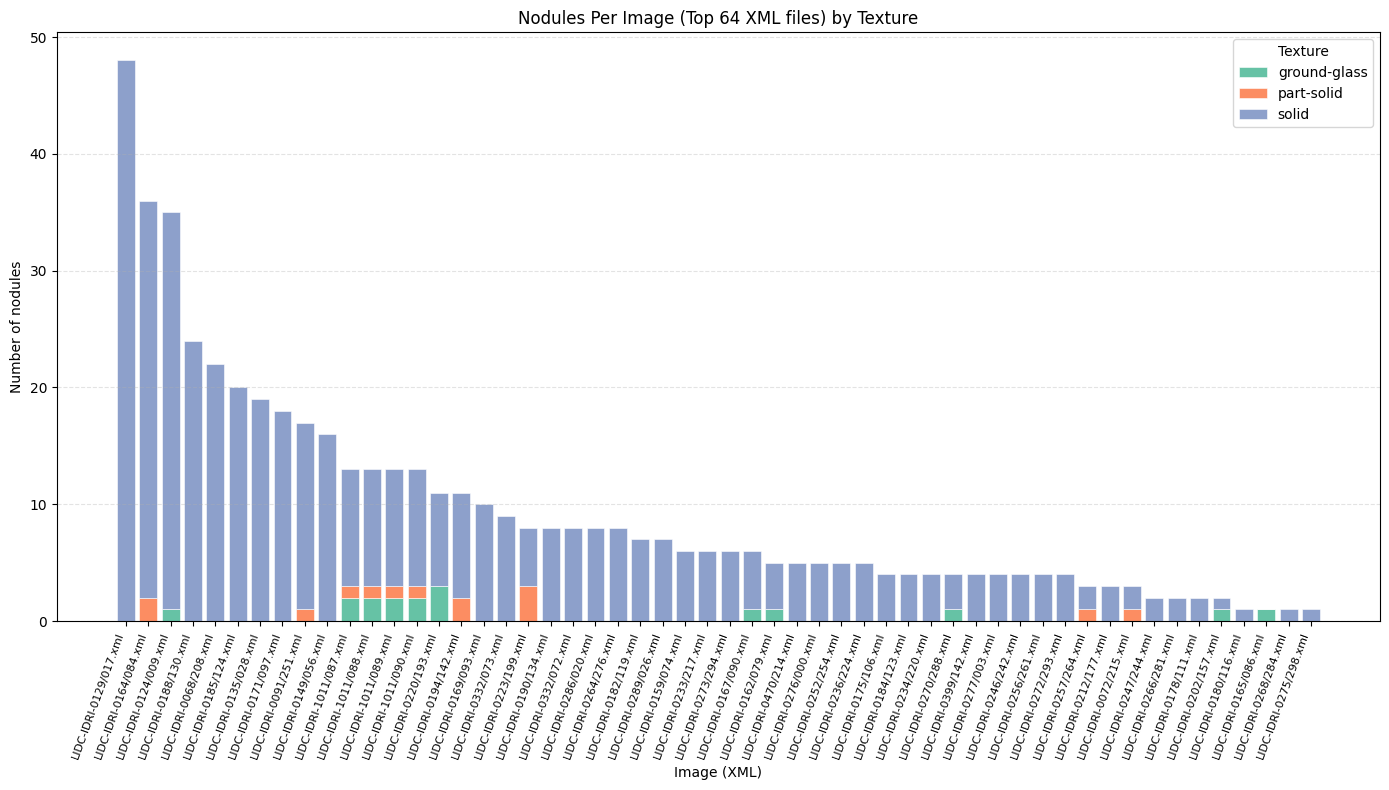

In [30]:
plot_stacked_bar_top_n(counts_df, out_path=None, top_n=64)

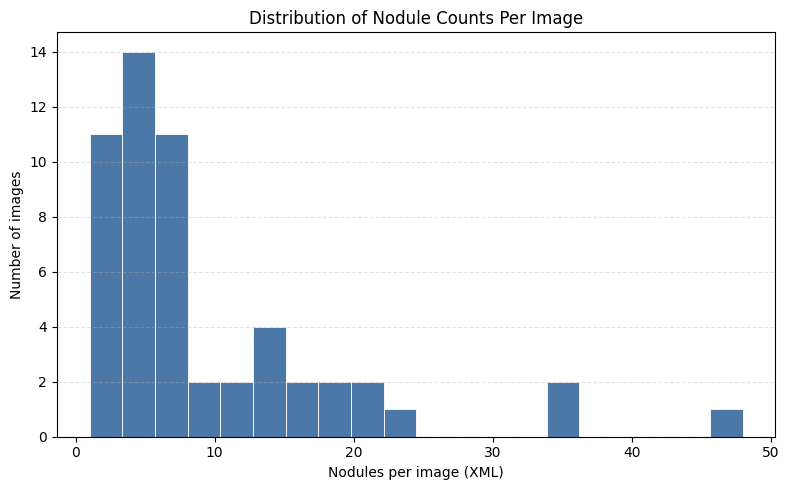

In [29]:
plot_nodule_count_histogram(counts_df, out_path=None)
